##### lerobot の キューブの移動の model ACT(lerobot/svla_so101_pickplace) を使った、学習用の pytorch コードです。  
学習データは、実際のデータを huggingface からダウンロードして使います。  
複雑な、lerobot の train を、自分で model class を使ってtrain することの材料になれば、幸いです。  
  
本コードを作成するにあたっては、Google Ai に、大変手助けをもらいました。  
また、チューニングに関しては、ChatGTP に、助けてもらいました。  
ありがとうと、感謝します。  
#### 動作確認  
実機での確認になります。  
act_using_example.py  
  
$ export PYTHONPATH=$PYTHONPATH:/home/your-id/local/git-download/lerobot/src  
$ lerobot_dataset_viz \  
  --repo-id lerobot/svla_so101_pickplace \  
  --episode-index 0



In [1]:
import os
# torchをインポートする前に設定
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [2]:
import os
import sys
from pathlib import Path

#export PYTHONPATH=$PYTHONPATH:/home/nishi/local/git-download/lerobot/src
# パスを通す（お使いの環境に合わせて絶対パスに書き換えてください）
# git clone をした、パスを使ってください。
lerobot_path = "/home/nishi/local/git-download/lerobot"
sys.path.append(os.path.join(lerobot_path, "src"))

from lerobot.configs.train import TrainPipelineConfig
from lerobot.scripts.lerobot_train import train
from lerobot.configs.policies import PreTrainedConfig
import torch.nn.functional as F

#batch_size=2
#batch_size=4
batch_size=8
# tarin を、継続するには、True
cont_f=True

use_motin_num=3

# lerobot ACT example を、なるべく再現したい場合 use_ex=False
# オリジナルの学習目安
#  2 epochs -> Loss:0.3
use_ex=True

input_shape=(3, 480, 640)
n_action_steps=100

if use_ex:
    input_shape=(3, 224, 224)
    n_action_steps=100


### dataset に delta_timestamps を挿入します。  
「ACTモデルの真価を発揮するため、現在から未来100ステップ分（約2秒間）の動作を一気に学習するように設定しました。
これにより、一貫性のある滑らかな動きが可能になります。」


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

len(dataset): 13127
frame.keys(): dict_keys(['observation.images.up', 'observation.images.side', 'action', 'observation.state', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'action_is_pad', 'task'])
img.shape: torch.Size([480, 640, 3])
type(img): <class 'torch.Tensor'>
img.max(): tensor(0.8510)


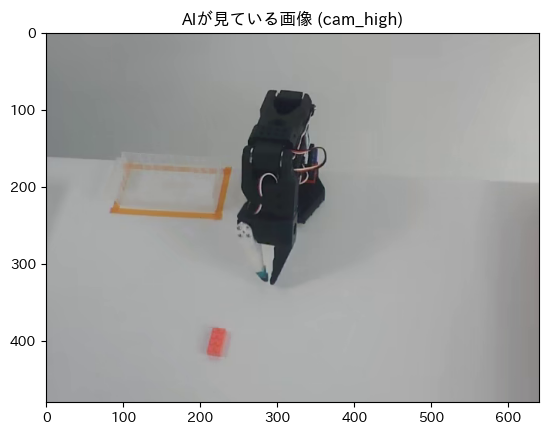

In [3]:
import matplotlib.pyplot as plt
import japanize_matplotlib # これを足すだけで日本語が使えるようになります
import torch

#from lerobot.datasets.lerobot_dataset import LeRobotDataset
from lerobot.datasets.lerobot_dataset import LeRobotDataset, LeRobotDatasetMetadata
from torch.utils.data import ConcatDataset, DataLoader

# データセットを直接読み込む
#dataset = LeRobotDataset("lerobot/aloha_static_pingpong_test")

# 1. 親となる共通のパス（環境に合わせて調整してください）
base_path = Path("outputs")

# 3つの分割データセットの正確なローカル絶対パス
path_motion1 = base_path / "split_dataset_0"
path_motion2 = base_path / "split_dataset_1"
path_motion3 = base_path / "split_dataset_2"

# 2. それぞれのデータセットを個別にロード
dataset1 = LeRobotDataset("motion1", root=path_motion1,
                        delta_timestamps={"action": [i/30 for i in range(n_action_steps)]} # 30Hzなので /30
                        )
dataset2 = LeRobotDataset("motion2", root=path_motion2,
                        delta_timestamps={"action": [i/30 for i in range(n_action_steps)]} # 30Hzなので /30
                        )
if use_motin_num==3:
    dataset3 = LeRobotDataset("motion3", root=path_motion3,
                        delta_timestamps={"action": [i/30 for i in range(n_action_steps)]} # 30Hzなので /30
                        )

# 3. 【今回の核心】PyTorchの機能で、メモリ上で1つに結合！
if use_motin_num==3:
    dataset = ConcatDataset([dataset1, dataset2, dataset3])
else:
    dataset = ConcatDataset([dataset1, dataset2])

if False:
    # 正確なローカル絶対パスを指定
    #local_dataset_path = Path("outputs/datasets/my_local_aloha_split_task")
    local_dataset_path = Path("outputs/split_dataset_0")
    
    # メタデータとデータセットをローカルから直接生成
    dataset_metadata = LeRobotDatasetMetadata("my_local_aloha_split_task", root=local_dataset_path)
    
    # (※ delta_timestamps が定義されているセルの後ろで以下を実行してください)
    dataset = LeRobotDataset("my_local_aloha_split_task", root=local_dataset_path, 
                             #delta_timestamps=delta_timestamps
                             delta_timestamps={"action": [i/50 for i in range(n_action_steps)]} # 50Hzなので /50
                            )
# Load original Dataset
if True:
    DATASET_ID = "lerobot/svla_so101_pickplace"
    # データセットを作るコードを探して、delta_timestamps を追加します
    dataset_org = LeRobotDataset(
        DATASET_ID,
        delta_timestamps={"action": [i/30 for i in range(n_action_steps)]} # 30Hzなので /30
    )

#print('dataset.features:',dataset.features)
print('len(dataset):',len(dataset))
channel_first=True
if True:
    # 最初の1コマ（1ステップ分）をのぞき見
    frame = dataset[0]
    print('frame.keys():',frame.keys())
    # model inputs は、(3,480,640) で、色順は、RGB です。
    # plt.imshow()は、デフォルトでRGB（赤・緑・青）の順序 なので、 model の入力も RGB のままです。
    # 2. 画像を表示してみる (PyTorchの [C, H, W] 形式を pillow.show 用の [H, W, C] に変換)
    if channel_first:
        img = frame["observation.images.up"].permute(1, 2, 0)
    else:
        img = frame["observation.images.up"].cpu().numpy()
    print('img.shape:',img.shape)  # img.shape: torch.Size([480, 640, 3]) これは、あくまで、pillow 用です。
    print('type(img):',type(img))
    print('img.max():',img.max())
    #print('img:',img)
    plt.imshow(img)
    plt.title("AIが見ている画像 (cam_high)")
    plt.show()


In [4]:
#print(dataset.meta)
# 1. デバイスの定義 (すでに定義済みの場合は不要)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. メタデータから統計情報を取得し、Tensorに変換して転送
# v3では stats_dict が meta オブジェクト内に格納されています
state_mean_list = dataset_org.meta.stats["observation.state"]["mean"]
state_mean = torch.tensor(state_mean_list, dtype=torch.float32).to(device)
state_std_list = dataset_org.meta.stats["observation.state"]["std"]
state_std = torch.tensor(state_std_list, dtype=torch.float32).to(device)

action_mean_list = dataset_org.meta.stats["action"]["mean"]
action_mean = torch.tensor(action_mean_list, dtype=torch.float32).to(device)
action_std_list = dataset_org.meta.stats["action"]["std"]
action_std = torch.tensor(action_std_list, dtype=torch.float32).to(device)

print('state_mean:',state_mean)
print('state_std:',state_std)
print('action_mean:',action_mean)
print('action_std:',action_std)

import gc
# 2. 不要になったデータセットを削除して解放
del dataset_org
gc.collect()

state_mean: tensor([  7.9870, -55.1808,  66.7763,  69.2525, -53.4389,   8.1123],
       device='cuda:0')
state_std: tensor([44.4918, 36.8270, 27.7084, 13.0132, 17.7030,  8.4048], device='cuda:0')
action_mean: tensor([  8.0211, -55.9624,  65.2557,  69.1819, -53.4199,   6.8489],
       device='cuda:0')
action_std: tensor([44.5630, 36.4851, 29.0120, 13.2381, 17.7644,  8.9990], device='cuda:0')


3333

In [5]:
#%%writefile ResizeWithPadTensor.py
import torch
import torch.nn.functional as F
class ResizeWithPadTensor:
    def __init__(self, size=(224,224)):
        self.target_h = size[0]
        self.target_w = size[1]
    def __call__(self, img):
        # --------------------------------
        # img:
        # [B,C,H,W]
        # --------------------------------
        B, C, H, W = img.shape
        # --------------------------------
        # scale
        # --------------------------------
        scale = min(
            self.target_w / W,
            self.target_h / H
        )
        new_w = int(W * scale)
        new_h = int(H * scale)
        # --------------------------------
        # resize
        # --------------------------------
        img = F.interpolate(
            img,
            size=(new_h, new_w),
            mode="bilinear",
            align_corners=False
        )
        # --------------------------------
        # padding size
        # --------------------------------
        pad_left = (self.target_w - new_w) // 2
        pad_right = self.target_w - new_w - pad_left
        pad_top = (self.target_h - new_h) // 2
        pad_bottom = self.target_h - new_h - pad_top
        # --------------------------------
        # pad
        # F.pad order:
        # (left,right,top,bottom)
        # --------------------------------
        img = F.pad(
            img,
            (
                pad_left,
                pad_right,
                pad_top,
                pad_bottom
            ),
            value=0
        )
        return img

In [6]:
from torch.utils.data import DataLoader
# 1. 教科書（DataLoader）の準備
# num_workers=0 は先ほどのエラー回避のためです
train_loader = DataLoader(
    dataset, 
    #dataset_n, 
    batch_size=batch_size,
    shuffle=True, 
    num_workers=0
)
from torchvision import transforms
# 1. 特訓メニュー（オーグメンテーション）の定義
if use_ex:
    train_transform = transforms.Compose([
        # --------------------------------
        # ResNet18 backbone 用
        # --------------------------------
        # 1. ToTensor() を削除し、こちらに差し替えます（Tensor型を float32 にして255で割る）
        # 注、下記は、不要みたい!!
        #transforms.Lambda(lambda x: x.float() / 255.0), 
        #transforms.Resize((224,224)),
        ResizeWithPadTensor((224,224)),
        # augmentation
        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1,
            saturation=0.1,
            hue=0.05
        ),
        # normalize
        transforms.Normalize(
            mean=[0.485,0.456,0.406], # 赤・緑・青の平均値
            std=[0.229,0.224,0.225]   # 標準偏差
        )
    ])
else:
    train_transform = transforms.Compose([
        # --------------------------------
        # ResNet18 backbone 用
        # --------------------------------
        # 1. ToTensor() を削除し、こちらに差し替えます（Tensor型を float32 にして255で割る）
        # 注、下記は、不要みたい!!
        #transforms.Lambda(lambda x: x.float() / 255.0), 
        #transforms.Resize((224,224)),
        #ResizeWithPadTensor((224,224)),
        # augmentation
        #transforms.ColorJitter(
        #    brightness=0.1,
        #    contrast=0.1,
        #    saturation=0.1,
        #    hue=0.05
        #),
        # normalize
        transforms.Normalize(
            mean=[0.485,0.456,0.406], # 赤・緑・青の平均値
            std=[0.229,0.224,0.225]   # 標準偏差
        )
    ])
    


#### この cell の cfg: の値が、ACTConfig() の 参考になります・

In [7]:
if False:
    from pathlib import Path
    import torch
    from lerobot.configs import FeatureType
    from lerobot.datasets import LeRobotDataset, LeRobotDatasetMetadata
    from lerobot.policies import make_pre_post_processors
    from lerobot.policies.act import ACTConfig, ACTPolicy
    from lerobot.utils.feature_utils import dataset_to_policy_features
    
    # This specifies the inputs the model will be expecting and the outputs it will produce
    dataset_metadata = LeRobotDatasetMetadata(DATASET_ID)
    features = dataset_to_policy_features(dataset_metadata.features)
    
    output_features = {key: ft for key, ft in features.items() if ft.type is FeatureType.ACTION}
    input_features = {key: ft for key, ft in features.items() if key not in output_features}
    
    cfg = ACTConfig(input_features=input_features, output_features=output_features)
    print('cfg:',cfg)
    #cfg: ACTConfig(n_obs_steps=1, 
    # input_features={'observation.state': PolicyFeature(type=<FeatureType.STATE: 'STATE'>, shape=(6,)), 
    # 'observation.images.up': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>, shape=(3, 480, 640)), 
    # 'observation.images.side': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>, shape=(3, 480, 640))}, 
    # output_features={'action': PolicyFeature(type=<FeatureType.ACTION: 'ACTION'>, shape=(6,))}, 
    # device='cuda', 
    # use_amp=False, 
    # use_peft=False, 
    # push_to_hub=True, 
    # repo_id=None, 
    # private=None, 
    # tags=None, 
    # license=None, 
    # pretrained_path=None, 
    # chunk_size=100, 
    # n_action_steps=100, 
    # normalization_mapping={'VISUAL': <NormalizationMode.MEAN_STD: 'MEAN_STD'>, 'STATE': <NormalizationMode.MEAN_STD: 'MEAN_STD'>, 'ACTION': <NormalizationMode.MEAN_STD: 'MEAN_STD'>}, 
    # vision_backbone='resnet18', 
    # pretrained_backbone_weights='ResNet18_Weights.IMAGENET1K_V1', 
    # replace_final_stride_with_dilation=False, 
    # pre_norm=False, 
    # dim_model=512, 
    # n_heads=8, 
    # dim_feedforward=3200, 
    # feedforward_activation='relu', 
    # n_encoder_layers=4,
    # n_decoder_layers=1,
    # use_vae=True,
    # latent_dim=32,
    # n_vae_encoder_layers=4,
    # temporal_ensemble_coeff=None,
    # dropout=0.1,
    # kl_weight=10.0,
    # optimizer_lr=1e-05,
    # optimizer_weight_decay=0.0001,
    # optimizer_lr_backbone=1e-05)


### オリジナルの ACT class(lerobot/svla_so101_pickplace) を、使います。  
lerobot/src/lerobot/policies/act/modeling_act.py  
class ACT(nn.Module):  
inputs:  
camera 入力が、2 個になります。  
アームのセンサーは、同じ 6 個 だと思う。  
outputs:  
アームの 6 個のサーボの位置を示す数値データ。  

In [8]:
import torch
# 公式の policy（モデル）から直接インポートします
from lerobot.policies.act.modeling_act import ACT
from lerobot.policies.act.configuration_act import ACTConfig

from lerobot.configs.types import FeatureType
from lerobot.configs.policies import PolicyFeature

# 1. 公式の「設定シート」を作ります
config = ACTConfig(
    device="cuda",
    #n_action_steps=100,
    n_action_steps=n_action_steps,
    input_features={
        "observation.environment_state": PolicyFeature(
            type=FeatureType.STATE,
            #shape=(14,)
            shape=(6,)
        ),
        #"observation.images": PolicyFeature(
        #    type=FeatureType.VISUAL,
        #    shape=(3, 480, 640)
        #),
        "observation.images.up": PolicyFeature(
            type=FeatureType.VISUAL,
            #shape=(3, 224, 224)
            shape=input_shape
        ),
        "observation.images.side": PolicyFeature(
            type=FeatureType.VISUAL,
            #shape=(3, 224, 224)
            shape=input_shape
        ),
    },
    output_features={
        "action": PolicyFeature(
            type=FeatureType.ACTION,
            #shape=(14,)
            shape=(6,)
        )
    },
    n_encoder_layers=4,
    #n_decoder_layers=7,
    n_decoder_layers=1,
    dim_model=512,
    dim_feedforward=3200,
    #chunk_size=100,
    chunk_size=n_action_steps,
)

# 1. 脳（SimpleACT）の準備
#device = "cuda" if torch.cuda.is_available() else "cpu"
#model = ACT(config).to(device)

#print('config:',config)
#config: ACTConfig(n_obs_steps=1, input_features={'observation.environment_state': PolicyFeature(type=<FeatureType.STATE: 'STATE'>, shape=(6,)), 'observation.images.up': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>, shape=(3, 224, 224)),
# 'observation.images.side': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>, shape=(3, 224, 224))}, 
# output_features={'action': PolicyFeature(type=<FeatureType.ACTION: 'ACTION'>, shape=(6,))}, 
# device='cuda', 
# use_amp=False, 
# use_peft=False, 
# push_to_hub=True, 
# repo_id=None, 
# private=None, 
# tags=None, 
# license=None, 
# pretrained_path=None, 
# chunk_size=100, 
# n_action_steps=100, 
# normalization_mapping={'VISUAL': <NormalizationMode.MEAN_STD: 'MEAN_STD'>, 'STATE': <NormalizationMode.MEAN_STD: 'MEAN_STD'>, 'ACTION': <NormalizationMode.MEAN_STD: 'MEAN_STD'>}, 
# vision_backbone='resnet18', 
# pretrained_backbone_weights='ResNet18_Weights.IMAGENET1K_V1', 
# replace_final_stride_with_dilation=False, 
# pre_norm=False, 
# dim_model=512, 
# n_heads=8, 
# dim_feedforward=3200, 
# feedforward_activation='relu', 
# n_encoder_layers=4, 
# n_decoder_layers=1, 
# use_vae=True, 
# latent_dim=32, 
# n_vae_encoder_layers=4, 
# temporal_ensemble_coeff=None, 
# dropout=0.1, 
# kl_weight=10.0, 
# optimizer_lr=1e-05, 
# optimizer_weight_decay=0.0001, 
# optimizer_lr_backbone=1e-05)



In [9]:
#2. 特訓ループ：1コマの「完コピ」実験
import torch.optim as optim
import torch
import numpy as np
from torch.optim.lr_scheduler import LambdaLR

global_step=0

out_dir="output/train_act"
if use_ex:
    out_dir="output/train_act_ex"
    
# 出力先のクラスフォルダを作成
if not os.path.exists(out_dir):
    os.makedirs(out_dir)
best_path = os.path.join(out_dir, "best_model.pth")
epoch_best_path = os.path.join(out_dir, "epoch_best_model.pth")

# 1. 脳（SimpleACT）の準備
device = "cuda" if torch.cuda.is_available() else "cpu"
# --- モデルは14軸で再構築 ---
model = ACT(config).to(device)

if False:
    print('model.backbone:',model.backbone)

# 2. 工具（Optimizer）の設定
# 1コマ集中特訓なので、少し強めの学習率(1e-4)で一気に覚えさせます
if use_ex:
    base_lr=1e-5
    base_weight_decay=1e-4
    backbone_lr = 3e-6
    backbone_weight_decay=1e-5
else:
    # optimizer_lr=1e-05, 
    # optimizer_weight_decay=0.0001, 
    # optimizer_lr_backbone=1e-05)
    base_lr=1e-5
    base_weight_decay=0.0001
    backbone_lr = 1e-5
    backbone_weight_decay=0.0001

if False:
    optimizer = optim.AdamW(model.parameters(), lr=base_lr)
else:
    # ----------------------------------------
    # parameter group 分離
    # ----------------------------------------
    backbone_params = []
    other_params = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        # --------------------------------
        # backbone 判定
        # --------------------------------
        if "backbone" in name:
            backbone_params.append(param)
        else:
            other_params.append(param)
    # debug
    print("backbone params :", len(backbone_params))
    print("other params    :", len(other_params))
    
    # ----------------------------------------
    # optimizer
    # ----------------------------------------
    optimizer = torch.optim.AdamW(
        [
            {
                "params": backbone_params,
                "lr": backbone_lr,     # 3e-6
                "weight_decay": backbone_weight_decay # 1e-5,
            },
            {
                "params": other_params,
                "lr": base_lr,        # 1e-5
                "weight_decay": base_weight_decay  # 1e-4,
            },
        ],
        #weight_decay=1e-4
    )

if cont_f:
    latest_check_pth=os.path.join(out_dir, "latest_checkpoint.pt")
    print('latest_check_pth:',latest_check_pth)
    #再開
    checkpoint = torch.load(
        #"checkpoint_50000.pt",
        latest_check_pth,
        map_location=device
    )
    global_step = checkpoint["step"]
    if global_step >= 50000:
        base_lr= 3e-6
    #optimizer = optim.AdamW(model.parameters(), lr=base_lr)
    #model.load_state_dict(torch.load(os.path.join(out_dir, "latest_model.pth")))
    model.load_state_dict(
        checkpoint["model"]
    )
    optimizer.load_state_dict(
        checkpoint["optimizer"]
    )
    model = model.to(device) # SOS, EOS, PADを含めて52クラス
    print(F'load model weight')

model.train()

#num_epochs=201
#num_epochs=1
# 最低、2 epochs 必要
# lerobot ACT のサンプルは、2 epochs Loss: 0.3 なので、これが目安
#num_epochs=2
num_epochs=3
#num_epochs=5
#num_epochs=6

num_warmup_steps = 200     # 最初の200回は徐々に体慣らし
num_training_steps = 1500  # 合計1500ステップ特訓

def lr_lambda(current_step: int):
    if current_step < num_warmup_steps:
        return float(current_step) / float(max(1, num_warmup_steps))
    return 1.0
scheduler = LambdaLR(optimizer, lr_lambda)

print(f"特訓開始 (Device: {device})...")
losses = []

best_loss = float('inf')
step_best_loss = float('inf')

min_loss=0.1
counter=0

if batch_size==8:
    check_steps=2500
elif batch_size==4:
    check_steps=5000
else:
    check_steps=10000
    
for epoch in range(num_epochs):
    total_loss = 0
    losses = []
    for step,batch_data in enumerate(train_loader):
        # データを整理してGPUへ
        #print('batch_data:',batch_data)
        # observation.images.top
        #img = batch_data["observation.images.cam_high"].to(device)
        
        # batch_data から画像を取り出した直後に適用
        img_raw_up = batch_data["observation.images.up"].to(device)
        img_raw_side = batch_data["observation.images.side"].to(device)

        torch.cuda.empty_cache()
        #print('img_raw.dtype:',img_raw.dtype,' img_raw.max():', img_raw.max())
        
        img_augmented_up = train_transform(img_raw_up)
        img_augmented_side = train_transform(img_raw_side)
        
        state = batch_data["observation.state"].to(device)
        # 未来100ステップの正解
        target = batch_data["action"].to(device)
        #print('target.shape:',target.shape)
        # batch_data の中身
        #target = batch_data["action"]        # [Batch, 100, 14]（最後は同じ値が並ぶ）
       
        # --------------------------------
        # normalize add by nishi 2026.5.15
        # --------------------------------
        state = (state - state_mean) / state_std
        target = (target - action_mean) / action_std
        
        is_pad = batch_data["action_is_pad"].to(device) # [Batch, 100]（本物ならFalse, 埋めた場所はTrue）

        #print('target.shape:',target.shape)
        #print('is_pad.shape:',is_pad.shape)        
        
        # --- 学習の4ステップ ---
        # A. 予測
        #pred = model(img_raw, state)
        #pred = model(img_augmented, state)
        if False:
            batch = {
                "observation.images.up": img_augmented_up,   # [B,3,H,W]
                "observation.images.side": img_augmented_side,   # [B,3,H,W]
                "observation.environment_state": state,    # [B,14]
                #"action": action,                         # [B,T,14] or [B,14]
                "action": target,
            }
        else:
            # act_training_example.py の値
            # batch = preprocessor(batch)
            # print('batch.keys():',batch.keys())
            # batch.keys(): dict_keys(['action', 'next.reward', 'next.done', 'next.truncated', 'info',
            #  'action_is_pad', 
            #  'observation.images.top_is_pad', 'task', 'index', 'task_index', 'episode_index', 
            #  'observation.images.top', 
            #  'observation.state'])
            # 注)
            # 'observation.images.top' は、policy.forward(batch) の中で、"observation.images" に変えているみたい。
            #print('is_pad:',is_pad)
            batch = {
                #"observation.images.top": img_augmented,
                #"observation.images": [img_augmented],   # [B,3,H,W]
                "observation.images": [img_augmented_up,img_augmented_side],   # [B,3,H,W]
                "observation.state": state,              # [B,14]
                #"observation.environment_state": state,  # これ、不要かも by nishi 2026.5.19
                "action": target,                        # # [B,T,14] or [B,14]
                # False = valid token
                #"action_is_pad": torch.zeros(
                #    target.shape[:2],
                #    dtype=torch.bool,
                #    device=target.device,
                #),
                "action_is_pad": is_pad,
            }
        
        #pred = model(batch)
        pred_actions, (mu, logvar) = model(batch)
        # /home/nishi/local/git-download/lerobot/src/lerobot/policies/act/modeling_act.py

        #print('pred.shape:',pred.shape)
        #print('pred:',pred)
        #print('pred[1]:',pred[1])
        if True:
            # offical code を、バックポートします。
            # --------------------------------
            # L1 loss (official style)
            # --------------------------------
            abs_err = F.l1_loss(target,pred_actions,reduction="none")

            # [B,T] -> [B,T,1]
            valid_mask = (~is_pad).unsqueeze(-1)
            # valid 要素数
            num_valid = (
                valid_mask.sum()
                * abs_err.shape[-1]
            )
            # masked mean
            l1 = (abs_err * valid_mask).sum() / num_valid.clamp_min(1)
            if config.use_vae:
                # --------------------------------
                # KL loss (official style)
                # --------------------------------
                kl = (
                    -0.5 * (
                        1 + logvar
                        - mu.pow(2)
                        - logvar.exp()
                    )
                ).sum(-1).mean()

                # --------------------------------
                # total
                # --------------------------------
                beta = 10.0
                loss = l1 + beta * kl
            else:
                loss=l1
        else:
            # こちらは、自分の今までの、バージョン あまり良くない!!
            # -----------------------------
            # Action reconstruction loss
            # -----------------------------
            # プロレベルのLoss計算のイメージ
            #loss = F.l1_loss(pred, target, reduction="none") # 一旦バラバラに計算
            #loss = loss[~is_pad].mean() # 本物のデータがある場所だけの平均を取る
            # 安全対策版のLoss計算
            l1 = F.l1_loss(pred_actions,target,reduction="none")
            if torch.any(~is_pad):
                l1 = l1[~is_pad].mean()
            else:
                l1 = l1.mean()
            # -----------------------------
            # KL loss
            # -----------------------------
            kl = -0.5 * torch.mean(
                1 + logvar - mu.pow(2) - logvar.exp()
            )
            # -----------------------------
            # Total ACT loss
            # -----------------------------
            beta = 10.0
            #beta = 1.0
            loss = l1 + beta * kl
        
        # C. 反省
        optimizer.zero_grad()
        loss.backward()
        
        # D. 改善（脳の更新）
        optimizer.step()
        scheduler.step() # 学習率の更新
        
        # 進捗表示
        losses.append(loss.item())
        #total_loss += loss.item()

        global_step+=1
        #if step % 200 == 0:
        #    print(f"Step {step:3d} | Loss: {loss.item():.6f}")
        # 定期ログ表示
        if global_step % 200 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"Steps {global_step:4d} | Loss: {loss.item():.6f} | LR: {current_lr:.6f}")
            if global_step > 1 and loss < step_best_loss and loss < 0.2 and loss > 0.1:
                step_best_loss = loss
                torch.save(model.state_dict(), best_path)
                print(f"Model saved! (Step Best Loss: {step_best_loss:.4f})")

        if global_step % check_steps == 0:
            checkpoint = {
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "step": global_step,
            }
            check_pth=os.path.join(out_dir, f"checkpoint_{global_step}.pt")
            latest_check_pth=os.path.join(out_dir, "latest_checkpoint.pt")
            torch.save(
                checkpoint,
                #"checkpoint_50000.pt"
                check_pth
            )
            torch.save(
                checkpoint,
                #"checkpoint_50000.pt"
                latest_check_pth
            )
            print(f"checkpoint saved! (checkpoint_{global_step}.pt)")

    #avg_loss = total_loss / len(train_loader)
    avg_loss = np.sum(losses) / len(losses)
    print(f"epoch {epoch:3d} | Loss: {avg_loss.item():.6f}")

    # 一番良いモデルを保存
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), epoch_best_path)
        print(f"Model saved! (Best Loss: {best_loss:.4f})")
        counter=0

print("\n--- 特訓完了！ ---")


backbone params : 20
other params    : 129
latest_check_pth: output/train_act_ex/latest_checkpoint.pt
load model weight
特訓開始 (Device: cuda)...
Steps 10200 | Loss: 0.314815 | LR: 0.000003
Steps 10400 | Loss: 0.298471 | LR: 0.000003
Steps 10600 | Loss: 0.274541 | LR: 0.000003
Steps 10800 | Loss: 0.346604 | LR: 0.000003
Steps 11000 | Loss: 0.341654 | LR: 0.000003
Steps 11200 | Loss: 0.277111 | LR: 0.000003
Steps 11400 | Loss: 0.237773 | LR: 0.000003
Steps 11600 | Loss: 0.266111 | LR: 0.000003
epoch   0 | Loss: 0.278693
Model saved! (Best Loss: 0.2787)
Steps 11800 | Loss: 0.264542 | LR: 0.000003
Steps 12000 | Loss: 0.346982 | LR: 0.000003
Steps 12200 | Loss: 0.277459 | LR: 0.000003
Steps 12400 | Loss: 0.260558 | LR: 0.000003
checkpoint saved! (checkpoint_12500.pt)
Steps 12600 | Loss: 0.225583 | LR: 0.000003
Steps 12800 | Loss: 0.180492 | LR: 0.000003
Model saved! (Step Best Loss: 0.1805)
Steps 13000 | Loss: 0.223113 | LR: 0.000003
Steps 13200 | Loss: 0.235139 | LR: 0.000003
epoch   1 | Los

In [10]:
latest_path = os.path.join(out_dir, "latest_model.pth")
# --- 5. 最後にモデルを保存 (Final Model) ---
torch.save(model.state_dict(), latest_path)
print(f"最終モデルを保存しました: {latest_path}")

stats_path = os.path.join(out_dir, "stats.pt")
stats = {
    "state_mean": state_mean.cpu(),
    "state_std": state_std.cpu(),
    "action_mean": action_mean.cpu(),
    "action_std": action_std.cpu(),
}
torch.save(
    stats,
    stats_path,
    #"output/train_act/stats.pt"
)
print("stats saved")



最終モデルを保存しました: output/train_act_ex/latest_model.pth
stats saved


In [11]:
# 学習に使っていない可能性が高い「最後の方のエピソード」から1コマ取る
if False:
    test_frame = dataset[len(dataset) - 1] 
    
    img_t = test_frame["observation.images.cam_high"].unsqueeze(0).to(device)
    state_t = test_frame["observation.state"].unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        prediction = model(img_t, state_t)
    
    print("未知の画像に対するAIの予測:\n", prediction[0, 0, :7])
    print("\n実際のお手本データ:\n", test_frame["action"][:7])
